In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
import numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader
from datetime import datetime
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import Counter
from itertools import product
import math
import hashlib
import io
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import patches
from matplotlib.patches import Patch
import json
from torch.utils.data import TensorDataset
from shared_utils import intersection_union, Preprocessor, scale_vars, preprocess_out_noise, make_model_hash
from graphing import plot_class_counter, average_pixel_value, pixels_outside_inside_hist, confusion_matrix_custom, score_across_datasets
from constants import IMG_HEIGHT, IMG_WIDTH, DATA_DIR
from torch import Tensor
import json
from matplotlib import gridspec

# Model definition

In [2]:
# TODO SET ALL NON USED TO NAN

In [3]:
SEED = 265
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)

In [4]:
TOTAL_ROWS, TOTAL_COLS = 2, 3
BATCH_SIZE = 32

In [5]:
EPOCH_INVESTIGATE_POINTS = [2,4,6,8,10]
MAX_EPOCHS = 10

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


In [7]:
save_dir = Path("imgs/object_detection")
save_dir.mkdir(parents=True, exist_ok=True)

In [8]:
DO_TRAINING = True  # Set me to TRUE to run training from the start, otherwise we just load existing models

In [9]:
# this is loaded to:
# 1. grab images
# 2. grab the actual transformed data, as a sanity check
dataset_train_imgs = torch.load(DATA_DIR / f"detection_train.pt", weights_only = False)
dataset_val_imgs = torch.load(DATA_DIR / f"detection_val.pt", weights_only = False)
dataset_test_imgs = torch.load(DATA_DIR / f"detection_test.pt", weights_only = False)

# we actually use these!
dataset_train = torch.load(DATA_DIR / f"list_y_true_train.pt", weights_only=False)
dataset_val = torch.load(DATA_DIR / f"list_y_true_val.pt", weights_only=False)
dataset_test = torch.load(DATA_DIR / f"list_y_true_test.pt", weights_only=False)

### Normalize Images

In [10]:
preprocessor = Preprocessor()
preprocessor.fit(dataset_train_imgs)

dataset_train_imgs = preprocessor.process(dataset_train_imgs)
dataset_val_imgs = preprocessor.process(dataset_val_imgs)
dataset_test_imgs = preprocessor.process(dataset_test_imgs)

Ok so dataset_train_imgs contains images and true 

In [11]:
print(len(dataset_train))
# looks like a good amount of data

26874


In [12]:
def global_to_local(x_g, y_g, w_g, h_g, rows=2, cols=3):
    # Determine cell size in normalized units
    cell_w = 1.0 / cols
    cell_h = 1.0 / rows

    # Find which cell the center (x, y) falls into
    col = int(x_g / cell_w)
    row = int(y_g / cell_h)

    # Constrain col/row to grid boundaries (safety for x_g=1.0)
    col = min(col, cols - 1)
    row = min(row, rows - 1)

    # Local x, y: position within the cell (0 to 1)
    x_local = (x_g - col * cell_w) / cell_w
    y_local = (y_g - row * cell_h) / cell_h

    # Local w, h: size relative to the cell size
    # (can be > 1 if box is bigger than the cell)
    w_local = w_g / cell_w
    h_local = h_g / cell_h

    return x_local, y_local, w_local, h_local, row, col

In [13]:
def local_to_global(x_l, y_l, w_l, h_l, row, col, rows=2, cols=3):
    cell_w = 1.0 / cols
    cell_h = 1.0 / rows

    # x_global = (number of cells to the left + offset within cell) * cell_width
    x_global = (col + x_l) * cell_w
    y_global = (row + y_l) * cell_h

    # w_global = w_local * cell_width
    w_global = w_l * cell_w
    h_global = h_l * cell_h

    return x_global, y_global, w_global, h_global

In [14]:
# sanity check from class:
global_to_local(0.6,0.6,0.2,0.2, rows=4, cols=3)

(0.8, 0.3999999999999999, 0.6000000000000001, 0.8, 2, 1)

In [15]:
# sanity check from class:
global_to_local(0.3,0.3,0.3,0.9, rows=4, cols=3)

(0.9, 0.19999999999999996, 0.9, 3.6, 1, 0)

Great, global to local is the same as the ones we computed in class!

Lets check using the pre-computed data

In [16]:
dataset_train_imgs[0][1][0][0]

tensor([1.0000, 0.7750, 0.8125, 0.3500, 0.7917, 1.0000])

In [17]:
dataset_train[0][0]

tensor([1.0000, 0.2583, 0.4062, 0.1167, 0.3958, 1.0000])

In [18]:
y_n, x,y,h,w,cla= dataset_train[0][0]
global_to_local(x,y,h,w)

(tensor(0.7750), tensor(0.8125), tensor(0.3500), tensor(0.7917), 0, 0)

OK! So global to local works and produces the same output as the preprocessed data. Happy days.

In [19]:
def plot_image(tensor_inp, ax):
    img_pixels, global_coords_ls = tensor_inp
    img = img_pixels.permute(1, 2, 0)

    ax.imshow(img)

    rows = 2
    cols = 3
    for r in range(1, rows):
        ax.axhline(y=r*IMG_HEIGHT/rows, color='white', linestyle='--', linewidth=1)
    for c in range(1, cols):
        ax.axvline(x=c*IMG_WIDTH/cols, color='white', linestyle='--', linewidth=1)

    items_in_img = set()

    for coords in global_coords_ls:
        is_item, x, y, w, h, class_label = coords
        items_in_img.add(int(class_label))

        scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x, y, w, h)

        ax.add_patch(
            patches.Rectangle(
                (scaled_x, scaled_y),
                scaled_w,
                scaled_h,
                linewidth=1,
                edgecolor='r',
                facecolor='none'
            )
        )

    ax.set_title(f"Image with class(es) {items_in_img}, has_item = {int(is_item)}")
    return ax

<Axes: title={'center': 'Image with class(es) {0, 1}, has_item = 1'}>

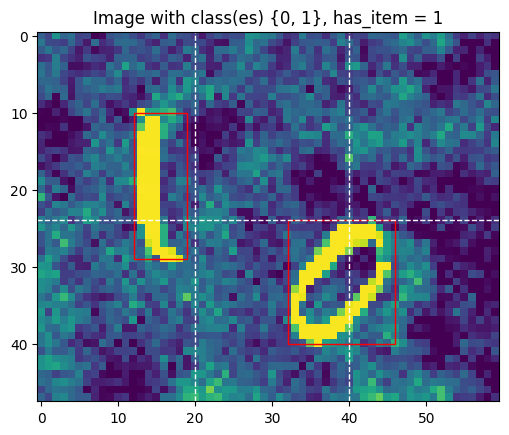

In [20]:
fig, axes = plt.subplots()

img = dataset_train_imgs[0][0]
global_coords = dataset_train[0]

plot_image((img, global_coords), axes)

In [21]:
global_coords = dataset_train[0][0]
actual_local = dataset_train_imgs[0][1][0][0]

is_item, x, y, h, w, class_item = global_coords

print("global cords:")
print(x,y,h,w)
print("\n")

x_loc, y_loc, w_loc, h_loc, _row, _col = global_to_local(x, y, h, w)

print("local cords:")
print(x_loc, y_loc, h_loc, w_loc)
print("\n")

print("actual local coords:")
print(actual_local)
print("\n")

col = int(x * TOTAL_COLS)
row = int(y * TOTAL_ROWS)

xg, yg, wg, hg = local_to_global(x_loc, y_loc, w_loc, h_loc, row, col)


print("global cords back again:")
print(xg, yg, hg, wg)
print("\n")

globals_check = [
        is_item,
        xg,
        yg,
        wg,
        hg,
        class_item
]

global cords:
tensor(0.2583) tensor(0.4062) tensor(0.1167) tensor(0.3958)


local cords:
tensor(0.7750) tensor(0.8125) tensor(0.7917) tensor(0.3500)


actual local coords:
tensor([1.0000, 0.7750, 0.8125, 0.3500, 0.7917, 1.0000])


global cords back again:
tensor(0.2583) tensor(0.4062) tensor(0.3958) tensor(0.1167)




<Axes: title={'center': 'Image with class(es) {1}, has_item = 1'}>

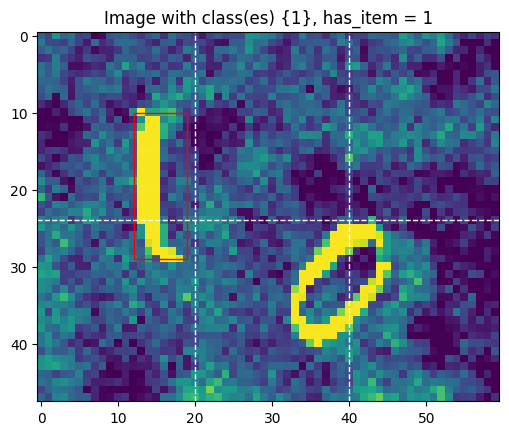

In [22]:
fig, axes = plt.subplots()
plot_image((img, [globals_check]), ax=axes)

Sanity check, yes we can convert the coordinates back and forth, great. Now let us combine the datasets, using our preprocessed items

In [23]:
# todo : do this efficent using pytorch
# TODO: build grid labels is wrong, put it right

dataset_train = [(dataset_train_imgs[i][0], dataset_train[i]) for i in range(len(dataset_train))]
dataset_val = [(dataset_val_imgs[i][0], dataset_val[i]) for i in range(len(dataset_val))]
dataset_test = [(dataset_test_imgs[i][0], dataset_test[i]) for i in range(len(dataset_test))]

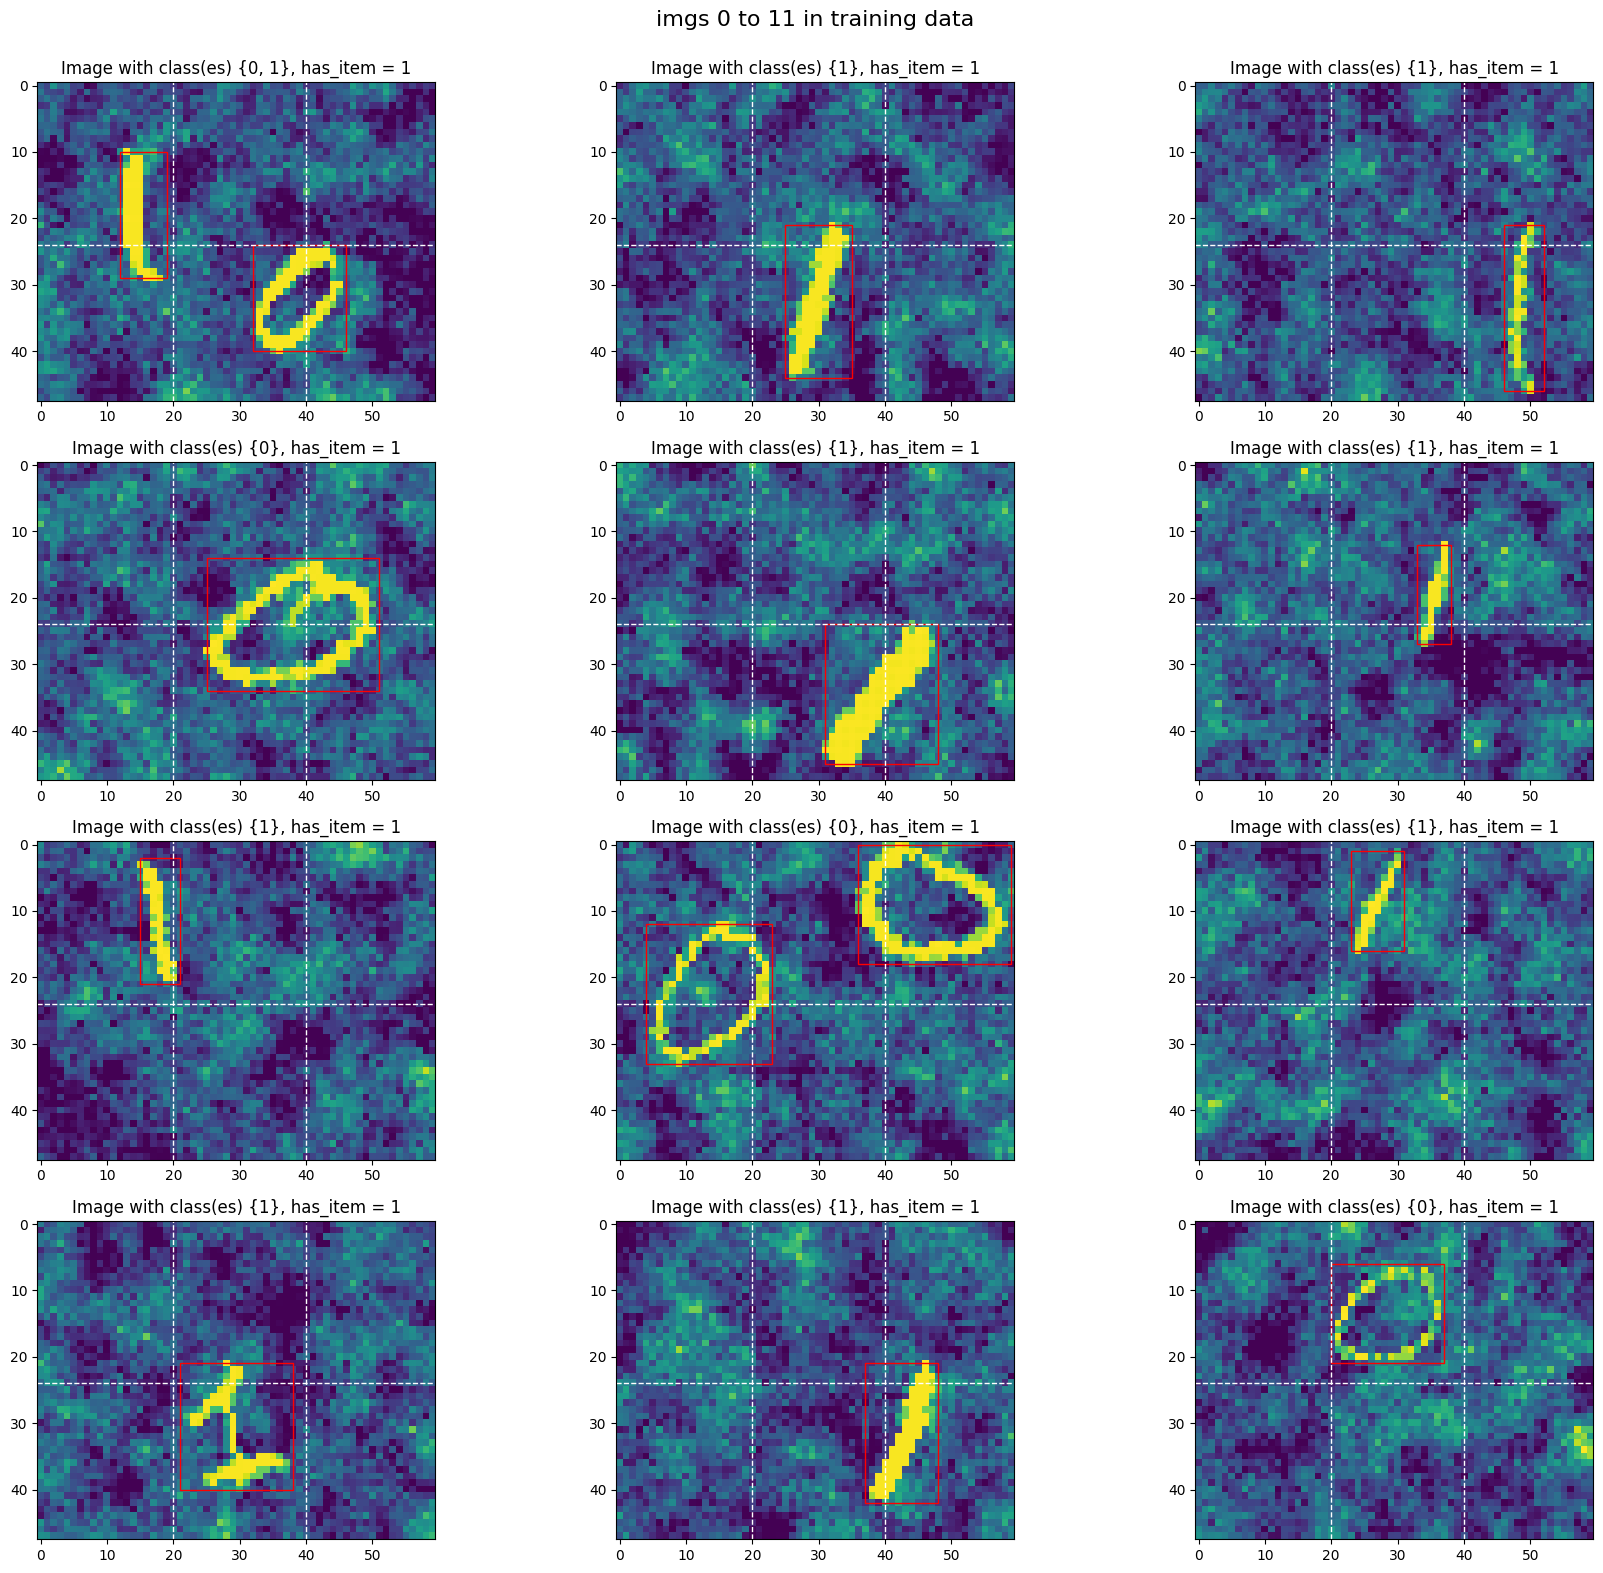

In [24]:
def plot_multiple(indicies: list, title: str, dataset, model_title):
    n = len(indicies)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"{title}", fontsize=16)

    for ax, index in zip(axes, indicies):
        plot_image(dataset[index], ax)

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(save_dir / f"{model_title}.png", dpi=500)

    plt.show()

plot_multiple(
    [i for i in range(12)],
    "imgs 0 to 11 in training data",
    dataset_train,
    "data_explore_train"
)

In [25]:
all_targets = [int(bb[5]) for label in dataset_train for bb in label[1]]

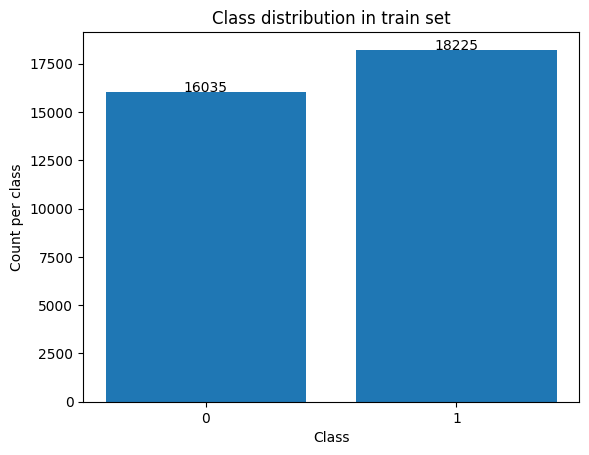

In [26]:
plot_class_counter(all_targets=all_targets, save_dir=save_dir)

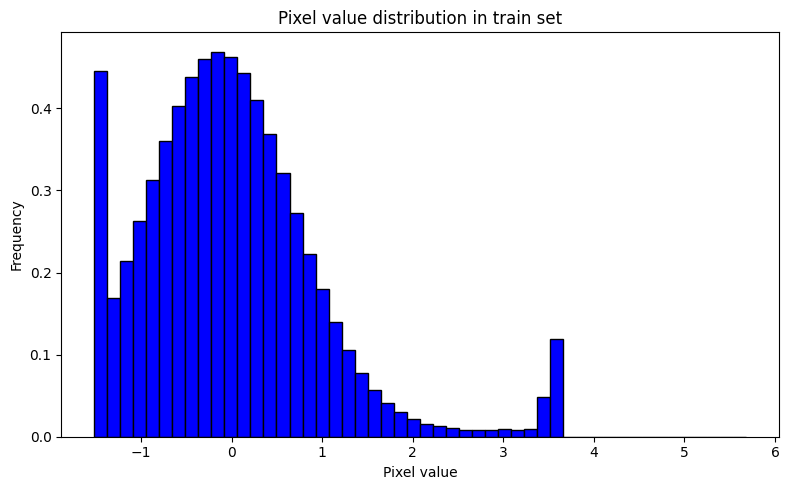

In [27]:
all_pixels = torch.cat([img_tensor[0].view(-1) for img_tensor in dataset_train])
average_pixel_value(all_pixels, save_dir)

In [28]:
def grab_pixels_inside_outside_bb(dataset):
    pixels_inside = []
    pixels_outside = []

    for img_tensor, bbs_list in dataset:
        _, H, W = img_tensor.shape
        # Use the first channel (grayscale/intensity) for the analysis
        img = img_tensor[0]

        # Create a master mask for this image (False = background)
        master_mask = torch.zeros(H, W, dtype=torch.bool)
        has_any_object = False

        for bb in bbs_list:
            # Unpack based on your dataset format: [is_item, x, y, h, w, class]
            is_item, x, y, h, w, _class = bb

            if is_item == 0:
                continue

            has_any_object = True

            # Convert normalized coordinates to pixel coordinates
            x_center, y_center = x * W, y * H
            w_px, h_px = w * W, h * H

            # Calculate bounds and clamp to image dimensions
            x1 = int(max(0, x_center - w_px / 2))
            x2 = int(min(W, x_center + w_px / 2))
            y1 = int(max(0, y_center - h_px / 2))
            y2 = int(min(H, y_center + h_px / 2))

            # Update the master mask
            master_mask[y1:y2, x1:x2] = True

        if not has_any_object:
            # If no objects, every pixel is "outside"
            pixels_outside.append(img.flatten())
        else:
            # Separate pixels based on the combined mask
            pixels_inside.append(img[master_mask])
            pixels_outside.append(img[~master_mask])

    # Concatenate all collected pixel values into two large tensors
    return torch.cat(pixels_inside), torch.cat(pixels_outside)

pixels_inside, pixels_outside = grab_pixels_inside_outside_bb(dataset_train)

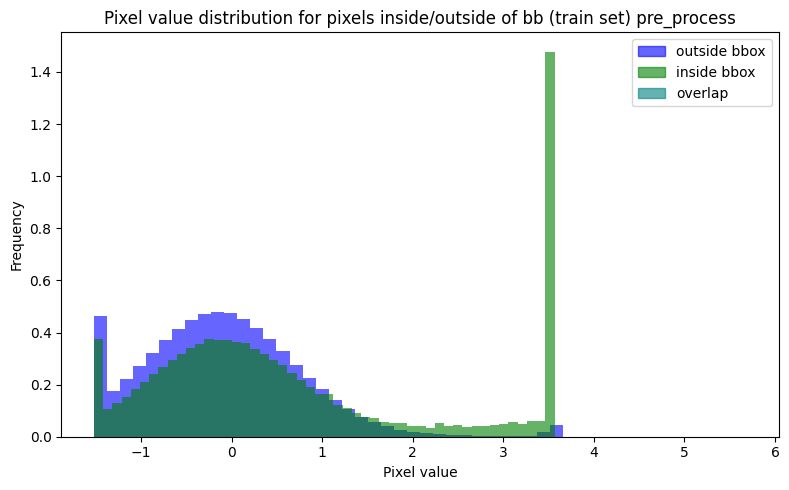

In [29]:
pixels_outside_inside_hist(pixels_inside, pixels_outside, save_dir, "pre_process")

In [30]:
dataset_train_processed = [preprocess_out_noise(sample ) for sample in dataset_train]
dataset_val_processed = [preprocess_out_noise(sample) for sample in dataset_val]
dataset_test_processed = [preprocess_out_noise(sample) for sample in dataset_test]

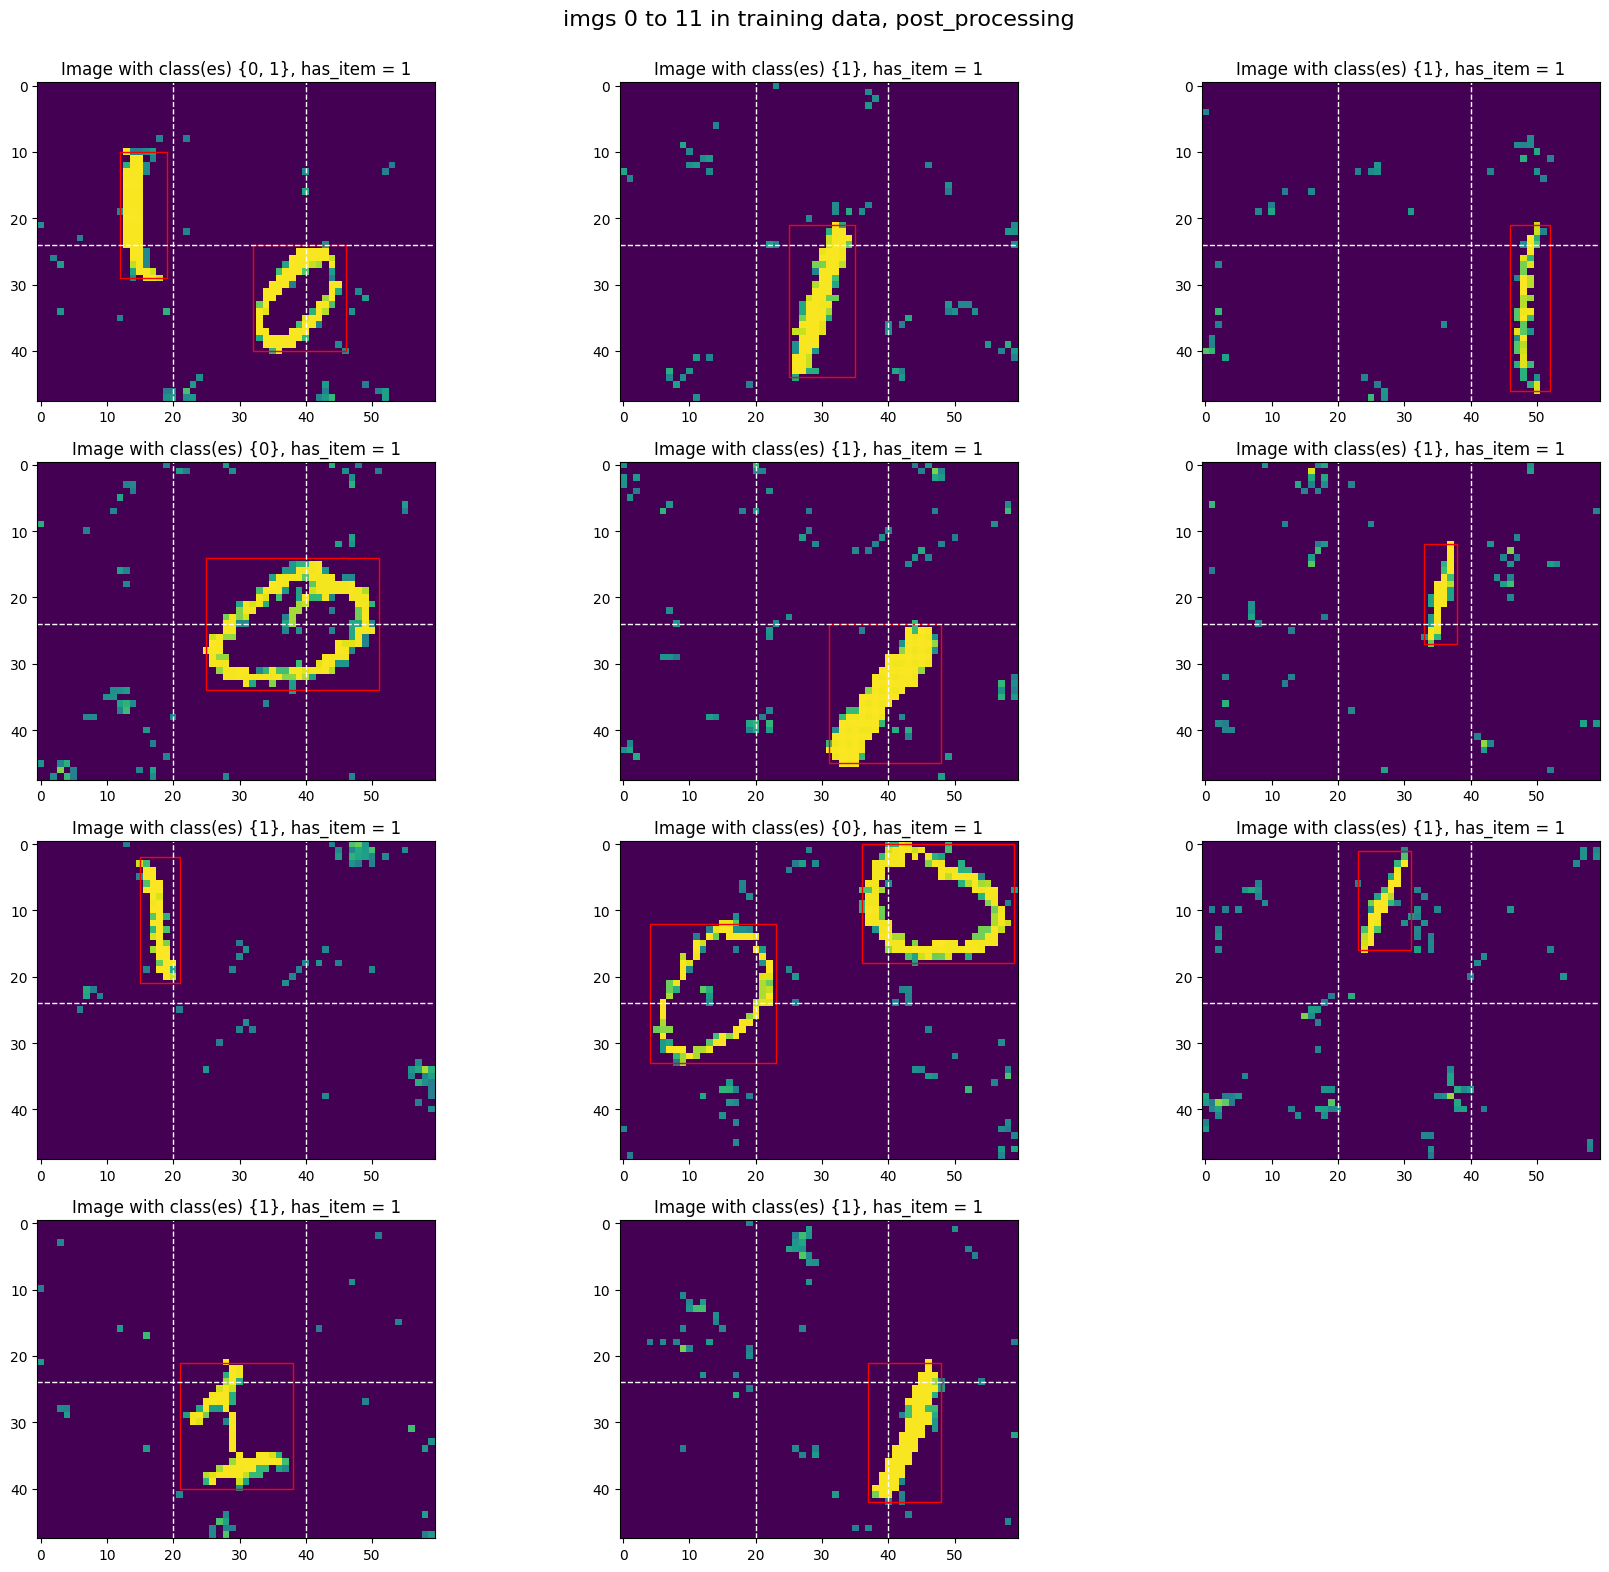

In [31]:
plot_multiple(
    [i for i in range(11)],
    "imgs 0 to 11 in training data, post_processing",
    dataset_train_processed,
    "data_explore_train_post_process"
)

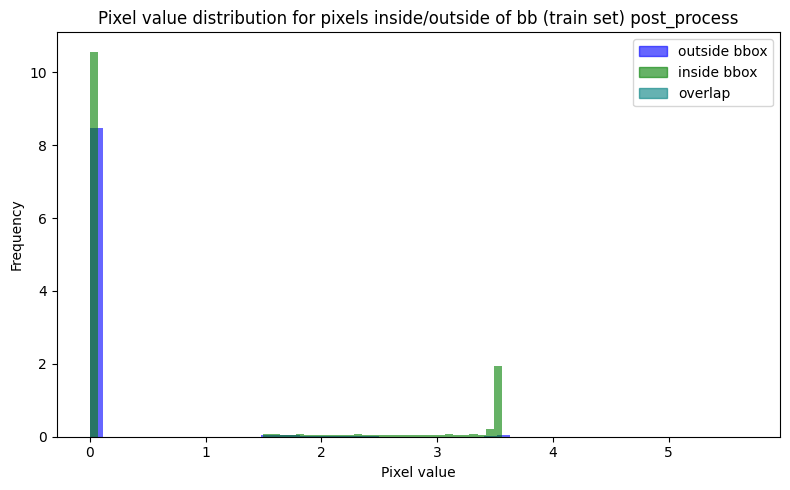

In [32]:
pixels_inside_processed, pixels_outside_processed = grab_pixels_inside_outside_bb(dataset_train_processed)
pixels_outside_inside_hist(pixels_inside_processed, pixels_outside_processed, save_dir=save_dir, label="post_process")

In [33]:
def build_grid_labels(global_labels_list, rows=2, cols=3):
    """
    Transforms a list of bounding boxes into a fixed (rows, cols, 6) tensor.
    Input format: [[is_item, x, y, h, w, class], ...]
    """
    # (2, 3, 6) -> [presence, x, y, w, h, class]
    grid = torch.zeros((rows, cols, 6))

    for bb in global_labels_list:
        is_item, x_g, y_g, h_g, w_g, class_label = bb

        if is_item == 0:
            continue

        xl, yl, wl, hl, row, col = global_to_local(x_g, y_g, w_g, h_g, rows, cols)

        grid[row, col, 0] = 1.0
        grid[row, col, 1] = xl
        grid[row, col, 2] = yl
        grid[row, col, 3] = wl
        grid[row, col, 4] = hl
        grid[row, col, 5] = class_label

    return grid

dataset_train_grid = [
    (dataset_train_processed[i][0], build_grid_labels(dataset_train_processed[i][1]))
    for i in range(len(dataset_train_processed))
]

dataset_val_grid = [
    (dataset_val_processed[i][0], build_grid_labels(dataset_val_processed[i][1]))
    for i in range(len(dataset_val_processed))
]

dataset_test_grid = [
    (dataset_test_processed[i][0], build_grid_labels(dataset_test_processed[i][1]))
    for i in range(len(dataset_test_processed))
]

In [34]:
train_loader_grid = DataLoader(dataset_train_grid, batch_size=BATCH_SIZE, shuffle=True)
# shuffle is true to let images go in a random order
val_loader_grid = DataLoader(dataset_val_grid, batch_size=BATCH_SIZE, shuffle=False)
test_loader_grid = DataLoader(dataset_test_grid, batch_size=BATCH_SIZE, shuffle=False)

In [35]:
logits_loss = nn.BCEWithLogitsLoss()
cross_entropy = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

def per_cell_localization_loss(pred, actual):
    """
    Loss function for a neural network with pred/actual vectors like:
    [
     z : is there an object in the image?
     x : coords
     y : coords
     w : coords
     h : coords
     c1 : class 1 probability
     c2
     c3
     ...
     c_n : class n probability
    ]
    """
    pred_flat = pred.reshape(-1, 7)
    actual_flat = actual.reshape(-1, 6)

    # grab all values
    z_actual, z_pred = actual_flat[:, 0], pred_flat[:, 0]
    bb_actual, bb_pred = actual_flat[:, 1:5], pred_flat[:, 1:5]
    class_actual, class_pred = actual_flat[:, 5].long(), pred_flat[:, 5:]

    # see what case we are in

    is_object_mask = z_actual == 1

    # both branches do this
    total_loss = logits_loss(z_pred, z_actual) # -log(sigmoid(z)), yes/no loss

    if is_object_mask.any():
        total_loss += mse_loss(bb_pred[is_object_mask], bb_actual[is_object_mask])
        total_loss += cross_entropy(class_pred[is_object_mask], class_actual[is_object_mask].long())
    return total_loss

## Localization


In [36]:
def get_map_results(model, eval_loader):
    '''
        Helper functions to get predictions and targets in the format required for mAP calculation.
        Depending on your data processing and model architecture this function can either be used as is, 
        modified to fit your needs or used as a blue print for a rewrite.
        Here it is assussmed that the image has been divide into a 2 x 3 grid.
        ----------------------------------------------------------
        Run through the data in the dataloader and collect predicitions and targets for mAP calculation.

        torchmetric mAP expects predictions and targets in the format:
        preds = [
            { "boxes": tensor([[x1, y1, x2, y2], ...]), "scores": tensor([score1, score2, ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        and targets = [
            { "boxes": tensor([[x1, y1, x2, y2], ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        where each dict in the list corresponds to one image in the dataset and contains the predicted and true results
    '''

    def xywh_to_xyxy(bb):
        # convert from center format to box format
        x_center, y_center, w, h = bb
        x1 = x_center - w/2
        y1 = y_center - h/2
        x2 = x_center + w/2
        y2 = y_center + h/2
        return x1, y1, x2, y2

    model.eval()
    with torch.no_grad():
        preds = []
        targets = []
        for images, labels in eval_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Ensure outputs are (B, 2, 3, 7) then flatten to (B, 6, 7)
            outputs = outputs.permute(0, 2, 3, 1) if outputs.shape[1] == 7 else outputs
            outputs = outputs.reshape(outputs.shape[0], -1, 7) 
            labels = labels.reshape(labels.shape[0], -1, 6)

            for output, label in zip(outputs, labels):
                pred_boxes, pred_scores, pred_labels = [], [], []
                target_boxes, target_labels = [], []

                for i, cell_output in enumerate(output):
                    # Unpack for clarity: [pc, x, y, w, h, class1_logit, class2_logit]
                    pc_logit = cell_output[0]

                    if torch.sigmoid(pc_logit) > 0.5:
                        obj_prob = torch.sigmoid(pc_logit).item()

                        # Fix: Get the class logits specifically
                        class_logits = cell_output[5:] 

                        # Only argmax if we actually have class channels
                        if class_logits.numel() > 0:
                            class_probs = F.softmax(class_logits, dim=0)
                            pred_label = torch.argmax(class_probs)
                            detect_score = obj_prob * class_probs[pred_label].item()

                            # Coordinate conversion: pass row/col explicitly
                            row, col = i // 3, i % 3
                            xl, yl, wl, hl = cell_output[1:5]

                            bbox_global = local_to_global(xl, yl, wl, hl, row, col)
                            bbox_xyxy = torch.stack(xywh_to_xyxy(bbox_global))

                            pred_boxes.append(bbox_xyxy)
                            pred_scores.append(detect_score)
                            pred_labels.append(pred_label)

                # Process labels (Targets)
                for i, cell_label in enumerate(label):
                    if cell_label[0] == 1:
                        row, col = i // 3, i % 3
                        xl, yl, wl, hl = cell_label[1:5]
                        bbox_global = local_to_global(xl, yl, wl, hl, row, col)
                        bbox_xyxy = torch.stack(xywh_to_xyxy(bbox_global))
                        target_boxes.append(bbox_xyxy)
                        target_labels.append(cell_label[5].long())

                # Formatting for MeanAveragePrecision
                if not pred_boxes:
                    preds.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device)
                    })
                else:
                    preds.append({
                        "boxes": torch.stack(pred_boxes),
                        "scores": torch.tensor(pred_scores, device=device),
                        "labels": torch.stack(pred_labels)
                    })

                if not target_boxes:
                    targets.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device)
                    })
                else:
                    targets.append({
                        "boxes": torch.stack(target_boxes),
                        "labels": torch.stack(target_labels)
                    })

    metric = MeanAveragePrecision(iou_type="bbox")
    metric.update(preds, targets)
    return metric.compute()


### Training

same conf = p - (k-1) / 2
dim_new = ((dim_old - k + 2padding) / stride) +1

In [37]:
class ModelOutcome:
    def __init__(
        self,
        train_losses: list,
        val_losses: list,
        params: dict,
        train_performance_metrics: list[float],
        val_performance_metrics: list[float],
        model_path: Path,
    ):
        self.train_losses = train_losses
        self.val_losses = val_losses

        self.params = params

        self.train_performance_metrics = train_performance_metrics
        self.val_performance_metrics = val_performance_metrics

        self.model_path = model_path

    def to_dict(self) -> dict:
        return {
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "params": self.params,
            "train_performance_metrics": self.train_performance_metrics,
            "val_performance_metrics": self.val_performance_metrics,
            "model_path": str(self.model_path) if self.model_path else None,
        }

    @staticmethod
    def from_dict(d: dict):
        return ModelOutcome(
            train_losses=d["train_losses"],
            val_losses=d["val_losses"],
            params=d["params"],
            train_performance_metrics={int(k): v for k, v in d["train_performance_metrics"].items()},
            val_performance_metrics={int(k): v for k, v in d["val_performance_metrics"].items()},
            model_path=Path(d["model_path"]) if d.get("model_path") else None,
        )

In [38]:
# not perfect yet
def non_max_supression(bounding_boxes, confidences):
    """
    bb input are in local form
    """
    global_boxes = [local_to_global(bb) for bb in bounding_boxes]

    # todo sort bounding boxes by confidences
    sorted(confidences)

    to_keep = []
    while global_boxes:
        confident_box = confidences.pop()
        to_keep.append(confident_box)

        for other_box in confidences:
            if intersection_union(confident_box, other_box) > 0.5:
                global_boxes.remove(other_box)

    return global_boxes

In [39]:
class CNNDetection(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # 1. Feature Extraction (Similar to your current layers)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 48x60 -> 24x30

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 24x30 -> 12x15

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 12x15 -> 6x7 (since 15/2 floor = 7)
        )

        # 2. Reaching the Grid: Final reduction to 2x3
        # AdaptiveAvgPool2d ensures we get exactly 2x3 regardless of input rounding
        self.grid_pool = nn.AdaptiveAvgPool2d((2, 3))

        # 3. Predictor: Replace Linear layers with 1x1 Convolutions
        # Output channels: pc(1) + coords(4) + classes(num_classes) = 7
        self.predictor = nn.Conv2d(64, 5 + num_classes, kernel_size=1)

    def forward(self, x):
        x = self.features(x)   # (B, 64, 6, 7)
        x = self.grid_pool(x) # (B, 64, 2, 3)
        x = self.predictor(x) # (B, 7, 2, 3)

        # Rearrange to match y_true shape: (B, 2, 3, 7)
        return x.permute(0, 2, 3, 1)

    def name(self):
        return "CNNDetection"

In [40]:
def train(
    n_epochs,
    optimizer,
    model,
    loss_fn,
    train_loader_inp: DataLoader,
    validation_loader_inp: DataLoader,
):
    n_batch_train = len(train_loader_inp)
    n_batch_val = len(validation_loader_inp)

    losses_train, losses_val = [], []
    train_performance_metrics, val_performance_metrics = {}, {}

    model.train()  # set to train mode
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(1, n_epochs + 1):
        loss_train, loss_val = 0.0, 0.0

        for imgs, labels in train_loader_inp:
            imgs = imgs.to(device=device, dtype=torch.float32)
            labels = labels.to(device=device)

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()

        model.eval()  # observe model performance
        with torch.no_grad():
            for val_imgs, val_labels in validation_loader_inp:
                imgs_val = val_imgs.to(device=device, dtype=torch.float32)
                val_labels = val_labels.to(device=device, dtype=torch.float32)
                val_outputs = model(imgs_val)
                val_loss = loss_fn(val_outputs, val_labels)
                loss_val += val_loss.item()

        if epoch in EPOCH_INVESTIGATE_POINTS:
            # map_metric, obj_acc, class_acc
            train_performance_metrics[epoch] = get_map_results(model, train_loader_inp)
            val_performance_metrics[epoch] = get_map_results(model, validation_loader_inp)

        model.train()

        losses_train.append(loss_train / n_batch_train)
        losses_val.append(loss_val / n_batch_val)

        if epoch == 1 or epoch % 5 == 0:
            print(
                "{}  |  Epoch {}  |  Training loss {:.3f} Validation loss {:.3f}".format(
                    datetime.now().time(), epoch, loss_train / n_batch_train, loss_val / n_batch_val
                )
            )
    return losses_train, losses_val, train_performance_metrics, val_performance_metrics

In [41]:
model_baseline = CNNDetection().to(device)
per_cell_loss_localization = per_cell_localization_loss

In [42]:
if DO_TRAINING:
    object_detection_optimizer = optim.Adam(model_baseline.parameters())

    train_losses, validation_losses, train_performance_metrics, val_performance_metrics = train(
        n_epochs=MAX_EPOCHS,
        optimizer=object_detection_optimizer,
        model=model_baseline,
        loss_fn=per_cell_loss_localization,
        train_loader_inp=train_loader_grid,
        validation_loader_inp=val_loader_grid,
    )
# here

22:12:27.824562  |  Epoch 1  |  Training loss 0.422 Validation loss 0.294
22:14:11.685573  |  Epoch 5  |  Training loss 0.188 Validation loss 0.174
22:16:41.287372  |  Epoch 10  |  Training loss 0.140 Validation loss 0.137


In [43]:
print(train_losses)

[0.4224465475018535, 0.25427958718722776, 0.2229614288856586, 0.20400418853830724, 0.18803585868860995, 0.17322824001312256, 0.1596741066624721, 0.1534371410629579, 0.14572541565146474, 0.1403783538999657]


In [44]:
print(validation_losses)

[0.294232139504084, 0.22582642589845964, 0.21322399185549828, 0.19868866658659393, 0.1742712276917632, 0.15833681245003978, 0.15215645490154142, 0.14288672572502525, 0.14538798184805019, 0.13719539889084395]


In [45]:
print(json.dumps(train_performance_metrics[10],indent=2, default=str))

{
  "map": "tensor(0.2205)",
  "map_50": "tensor(0.6289)",
  "map_75": "tensor(0.0825)",
  "map_small": "tensor(0.2205)",
  "map_medium": "tensor(-1.)",
  "map_large": "tensor(-1.)",
  "mar_1": "tensor(0.3024)",
  "mar_10": "tensor(0.3413)",
  "mar_100": "tensor(0.3413)",
  "mar_small": "tensor(0.3413)",
  "mar_medium": "tensor(-1.)",
  "mar_large": "tensor(-1.)",
  "map_per_class": "tensor(-1.)",
  "mar_100_per_class": "tensor(-1.)",
  "classes": "tensor([0, 1], dtype=torch.int32)"
}


In [46]:
print(json.dumps(val_performance_metrics[10],indent=2, default=str))

{
  "map": "tensor(0.2226)",
  "map_50": "tensor(0.6238)",
  "map_75": "tensor(0.0863)",
  "map_small": "tensor(0.2226)",
  "map_medium": "tensor(-1.)",
  "map_large": "tensor(-1.)",
  "mar_1": "tensor(0.3037)",
  "mar_10": "tensor(0.3392)",
  "mar_100": "tensor(0.3392)",
  "mar_small": "tensor(0.3392)",
  "mar_medium": "tensor(-1.)",
  "mar_large": "tensor(-1.)",
  "map_per_class": "tensor(-1.)",
  "mar_100_per_class": "tensor(-1.)",
  "classes": "tensor([0, 1], dtype=torch.int32)"
}


In [52]:
def plot_train_val_losses(
    train_losses,
    val_losses,
    train_acc,
    val_acc,
    params=None,
    ax_plot=None,
    ax_table=None,
    title=None,
    figsize=(8, 5)
):
    """
    Plot training/validation loss and place a metrics table below the plot.
    """

    # if alone
    if ax_plot is None or ax_table is None:
        fig = plt.figure(figsize=figsize, constrained_layout=True)
        gs = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.05)
        ax_plot = fig.add_subplot(gs[0])
        ax_table = fig.add_subplot(gs[1])
    else:
        fig = None  # we are plotting inside existing axes

    epochs = range(1, len(train_losses) + 1)

    ax_plot.plot(epochs, train_losses, label="train loss")
    ax_plot.plot(epochs, val_losses, label="val loss")

    if title:
        ax_plot.set_title(title, pad=30)

    # Add top-left label outside axes but for each subplot
    ax_plot.text(
        -0.15,       # x slightly left of the axes (negative)
        1.05,        # y slightly above the axes
        "map:",
        transform=ax_plot.transAxes,
        fontsize=9,
        fontweight="bold",
        verticalalignment="bottom",
        horizontalalignment="left",
        color="black",
        bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=2)
    )


    row_class = []
    row_obj = []
    row_iou = []

    for epoch in EPOCH_INVESTIGATE_POINTS:

        v_map = val_acc[epoch]["map"]
        t_map = train_acc[epoch]["map"]

        row_class.append(f"{v_map:.2f}")
        # row_obj.append(f"{v_obj_acc:.2f}")
        # row_iou.append(f"{v_iou:.2f}")

        ax_plot.axvline(x=epoch, color="gray", linestyle="--", alpha=0.3)

        ax_plot.text(
            epoch,
            1.02,
            f"val:{((v_map) / 2):.2f}",
            transform=ax_plot.get_xaxis_transform(),
            color="orange",
            fontsize=9,
            ha="center",
            va="bottom",
        )

        ax_plot.text(
            epoch,
            1.08,
            f"train:{((t_map) / 2):.2f}",
            transform=ax_plot.get_xaxis_transform(),
            color="blue",
            fontsize=9,
            ha="center",
            va="bottom",
        )

    ax_plot.set_xlabel("Epoch")
    ax_plot.set_ylabel("Total Loss")
    ax_plot.legend()

    if params:
        param_text = "\n".join([f"{k}: {v}" for k, v in params.items()])

        props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)

        ax_plot.text(
            0.02,
            0.02,
            param_text,
            transform=ax_plot.transAxes,
            fontsize=8,
            verticalalignment="bottom",
            bbox=props,
        )

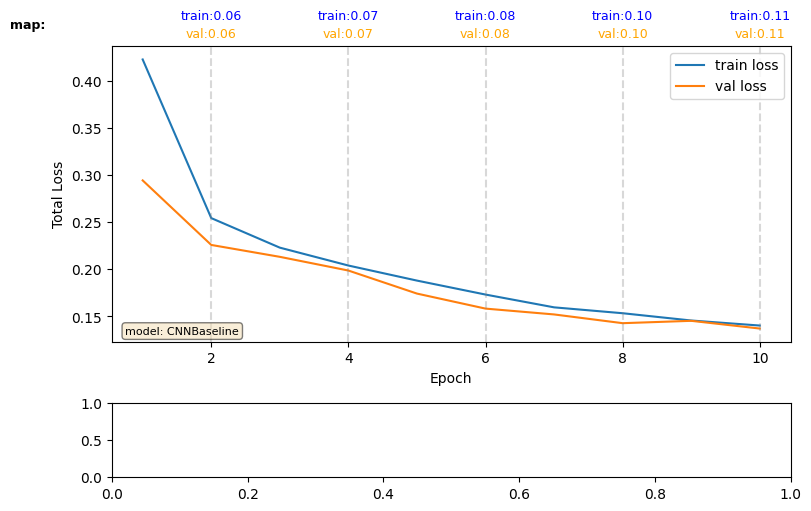

In [53]:
if DO_TRAINING:
    baseline_plot = plot_train_val_losses(
        train_losses=train_losses,
        val_losses=validation_losses,
        train_acc=train_performance_metrics,
        val_acc=val_performance_metrics,
        params={
            "model" : "CNNBaseline"
        },
    )
    baseline_plot

In [ ]:
learning_rate_ls = [1e-3, 1e-4]
weight_decay_ls = [0, 1e-4]

models = [CNNBaseline, CNNBaselineWithBatch, CNNWide, CNNDeep, CNNIncreasedKernelSize]

In [ ]:
all_model_outcomes: dict[list[ModelOutcome]] = {}

if DO_TRAINING:
    models_dir = Path("models")
    models_dir.mkdir(exist_ok=True)

    for model_class in models:
        params_and_losses: list[ModelOutcome] = []

        perms = product(learning_rate_ls, weight_decay_ls)
        model_count = (
            len(learning_rate_ls) * len(weight_decay_ls)
        )

        for index, hyperparams in enumerate(perms):
            torch.manual_seed(SEED)

            learning_rate, weight_decay = hyperparams
            model = model_class().to(device)

            optimizer = optim.Adam(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay,
            )

            train_losses, validation_losses, train_performance_metrics, val_performance_metrics = train(
                n_epochs=MAX_EPOCHS,
                optimizer=optimizer,
                model=model,
                loss_fn=per_cell_loss_localization,
                train_loader=train_loader_grid,
                validation_loader=val_loader_grid,
            )
            print(f"Trained {index} of {model_count} model permuations")

            params = {
                "model": model.name(),
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
            }

            model_hash = make_model_hash(model, params)
            model_path = models_dir / f"{model_hash}.pt"

            torch.save(model.state_dict(), model_path)

            model_outcome = ModelOutcome(
                train_losses=train_losses,
                val_losses=validation_losses,
                params=params,
                train_performance_metrics=train_performance_metrics,
                val_performance_metrics=val_performance_metrics,
                model_path=model_path,
            )

            params_and_losses.append(model_outcome)

        print(f"Finished training {model.name()}")
        all_model_outcomes[model.name()] = params_and_losses

    all_model_outcomes.keys()

NameError: name 'models' is not defined

In [ ]:
output_path = Path("data/saved/model_outcomes_detection.json")

In [ ]:
if DO_TRAINING:
    json.dump(
        {k: [m.to_dict() for m in v] for k, v in all_model_outcomes.items()},
        output_path.open("w"),
    )

In [ ]:
loaded_json = json.load(Path(output_path).open("r"))
all_model_outcomes = {
    k: [ModelOutcome.from_dict(m) for m in v] for k, v in loaded_json.items()
}

In [ ]:
def plot_all_runs(runs: list, model_title):

    n = len(runs)
    cols = 2
    rows = math.ceil(n / cols)

    fig = plt.figure(
        figsize=(6 * cols, 5.2 * rows),
        constrained_layout=True,
    )

    outer = gridspec.GridSpec(
        rows,
        cols,
        figure=fig,
        hspace=0.35,
        wspace=0.25
    )


    fig.suptitle(
        f"All runs for model type {model_title}",
        fontsize=16,
    )

    for i, model_outcome in enumerate(runs):

        r = i // cols
        c = i % cols

        inner = outer[r, c].subgridspec(
            2,
            1,
            height_ratios=[4, 1],
        )

        ax_plot = fig.add_subplot(inner[0])
        ax_table = fig.add_subplot(inner[1])

        plot_train_val_losses(
            train_losses=model_outcome.train_losses,
            val_losses=model_outcome.val_losses,
            train_acc=model_outcome.train_performance_metrics,
            val_acc=model_outcome.val_performance_metrics,
            params=model_outcome.params,
            ax_plot=ax_plot,
            ax_table=ax_table,
        )

    fig.savefig(
        save_dir / f"hyperparams_{model_title}.png",
        dpi=500,
        bbox_inches="tight",
    )

    plt.show()

In [ ]:
runs = all_model_outcomes["CNNBaseline"]
plot_all_runs(runs, "CNNBasline")

In [ ]:
best_model_outcome = None
best_score = -1.0
best_metrics = None
best_epoch = None

for model_name, runs in all_model_outcomes.items():
    for run in runs:
        for epoch, metrics in run.val_performance_metrics.items():
            # TODO FIX METRICS
            val_iou, val_obj_acc, val_class_acc = metrics

            # from pdf, this is overall performance
            current_score = (val_iou + val_class_acc) / 2

            if current_score > best_score:
                best_score = current_score
                best_metrics = metrics
                best_model_outcome = run
                best_epoch = epoch

print(f"Best model: {best_model_outcome.params['model']}")
print(f"Best Score: {best_score:.4f} (Metrics: {best_metrics}) at {best_epoch} epochs")
print(f"Model path: {best_model_outcome.model_path}")

In [ ]:
best_plot = plot_train_val_losses(
    train_losses=best_model_outcome.train_losses,
    val_losses=best_model_outcome.val_losses,
    train_acc=best_model_outcome.train_performance_metrics,
    val_acc=best_model_outcome.val_performance_metrics,
    params=best_model_outcome.params,
    title="Best model (based on validation score)"
)
plt.savefig(save_dir / "best_model.png")
plt.show()

In [ ]:
model_class_name = best_model_outcome.params["model"]

if model_class_name == "CNNBaselineNoBatch":
    best_model = CNNBaselineNoBatch().to(device)
... etc


In [ ]:
best_model.load_state_dict(torch.load(best_model_outcome.model_path))
best_model.eval()

### Predictions

In [ ]:
def grab_predictions(model, dataset):
    all_preds = []
    all_actual = []

    with torch.no_grad():
        for imgs, actual_vector in dataset:
            imgs = imgs.to(device, dtype=torch.float32)
            actual_vector = actual_vector.to(device)

            pred_vector = model(imgs)

            all_preds.append(pred_vector.cpu())
            all_actual.append(actual_vector.cpu())

    return torch.cat(all_preds, dim=0), torch.cat(all_actual, dim=0)

In [ ]:
# TODO

## Performance measure

In [ ]:
# num of layers affects size of receptive field
# kernel size affects ability to see complicated things
# we need to use MAP

# we could compute bounding boxes and accuracy

# since we can really have inifnite true negatives, we have to use precision

# precsion : TP / TP + FP <- we can abuse by placing few boxes
# recall : TP / TP + FN <- we can abuse by placing many many boxes

# MAP:
# mean precision is mean precision for one class

# if iou is more than half then we got a TP
# but if multiple, pick the one with highest IOU, rest are FN

### Model selection and evaluation

In [ ]:
def intersection(bb1, bb2):
    """
    Compute intersection between 2 bb, in global frame of ref
    """
    # TODO
   
def IoU(bb1, bb2):
    """
    Compute IoU given 2 bb (local or global)
    """
    #TODO
   
def compute_IoU_localization(model, loader, preprocessor):
    """
    Compute IoU performance of the model on the given dataset
    """
   #TODO

def compute_accuracy_localization(model, loader, preprocessor):
    """
    Compute accuracy of the model on the given dataset
    """
    #TODO
    

In [ ]:
def plot_image_with_predctions(tensor_inp, predictions_local, ax):
    img_pixels, global_coords_ls = tensor_inp
    img = img_pixels.permute(1, 2, 0)

    ax.imshow(img)

    rows = 2
    cols = 3
    for r in range(1, rows):
        ax.axhline(y=r*IMG_HEIGHT/rows, color='white', linestyle='--', linewidth=1)
    for c in range(1, cols):
        ax.axvline(x=c*IMG_WIDTH/cols, color='white', linestyle='--', linewidth=1)

    items_in_img = set()

    for coords in global_coords_ls:
        is_item, x, y, w, h, class_label = coords
        items_in_img.add(int(class_label))

        scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x, y, w, h)

        ax.add_patch(
            patches.Rectangle(
                (scaled_x, scaled_y),
                scaled_w,
                scaled_h,
                linewidth=1,
                edgecolor='r',
                facecolor='none'
            )
        )

    for coords in predictions_local:
        pred_x, pred_y, pred_w, pred_h = coords
        scaled_x_pred, scaled_y_pred, scaled_w_pred, scaled_h_pred = scale_vars(pred_x,pred_y,pred_w,pred_h)

        ax.add_patch(
            patches.Rectangle((scaled_x_pred, scaled_y_pred), scaled_w_pred, scaled_h_pred, linewidth=5, edgecolor='y', facecolor='none')
        )

    ax.legend(
        ["red", "yellow"],
        ["actual", "predicted"]
    )

    ax.set_title(f"Image with class(es) {items_in_img}, has_item = {int(is_item)}")
    return ax

fig, axes = plt.subplots()

img = dataset_train_imgs[0][0]
global_coords = dataset_train[0]

plot_image_with_predctions((img, global_coords),..., axes)